# 01 - CVE Data Exploration

This notebook explores the CVE (Common Vulnerabilities and Exposures) dataset to understand:
- Dataset size and structure
- Distribution of severity levels (CVSS scores)
- Most affected software/platforms
- Common vulnerability types
- Attack vector patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import re
import sys
sys.path.append('..')
from utils.preprocessing import classify_vulnerability_type, get_severity_label, extract_software_name

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect the Dataset

In [2]:
df = pd.read_csv('../data/cve_dataset.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Total CVEs: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
df.head(10)

Dataset Shape: (1314, 5)
Total CVEs: 1,314

Columns: ['CVE ID', 'Description', 'CVSS Score', 'Attack Vector', 'Affected OS']

Data Types:
CVE ID            object
Description       object
CVSS Score       float64
Attack Vector     object
Affected OS       object
dtype: object

Missing Values:
CVE ID             0
Description        0
CVSS Score         0
Attack Vector      0
Affected OS      883
dtype: int64


,CVE ID,Description,CVSS Score,Attack Vector,Affected OS
0,CVE-2024-21732,FlyCms through abbaa5a allows XSS via the perm...,6.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:L/I:L/A:N,NaN
1,CVE-2023-5877,The affiliate-toolkit WordPress plugin before ...,9.8,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,NaN
2,CVE-2023-6000,The Popup Builder WordPress plugin before 4.2....,6.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:C/C:L/I:L/A:N,NaN
3,CVE-2023-6037,The WP TripAdvisor Review Slider WordPress plu...,4.8,CVSS:3.1/AV:N/AC:L/PR:H/UI:R/S:C/C:L/I:L/A:N,NaN
4,CVE-2023-6064,The PayHere Payment Gateway WordPress plugin b...,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,NaN
5,CVE-2023-6113,The WP STAGING WordPress Backup Plugin before ...,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,NaN
6,CVE-2023-6271,The Backup Migration WordPress plugin before 1...,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,NaN
7,CVE-2023-6421,The Download Manager WordPress plugin before 3...,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,NaN
8,CVE-2023-6485,The Html5 Video Player WordPress plugin before...,5.4,CVSS:3.1/AV:N/AC:L/PR:L/UI:R/S:C/C:L/I:L/A:N,NaN
9,CVE-2024-0181,A vulnerability was found in RRJ Nueva Ecija E...,2.4,CVSS:3.1/AV:N/AC:L/PR:H/UI:R/S:U/C:N/I:L/A:N,NaN


In [3]:
# Basic statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total CVE entries: {len(df):,}")
print(f"CVSS Score range: {df['CVSS Score'].min()} - {df['CVSS Score'].max()}")
print(f"Mean CVSS Score: {df['CVSS Score'].mean():.2f}")
print(f"Median CVSS Score: {df['CVSS Score'].median():.2f}")
print(f"\nDescription length stats:")
desc_lengths = df['Description'].str.len()
print(f"  Min: {desc_lengths.min()} chars")
print(f"  Max: {desc_lengths.max()} chars")
print(f"  Mean: {desc_lengths.mean():.0f} chars")
print(f"  Median: {desc_lengths.median():.0f} chars")

DATASET OVERVIEW
Total CVE entries: 1,314
CVSS Score range: 2.2 - 10.0
Mean CVSS Score: 6.79
Median CVSS Score: 6.70

Description length stats:
  Min: 36 chars
  Max: 2238 chars
  Mean: 313 chars
  Median: 272 chars


## 2. CVSS Score Distribution (Severity Analysis)

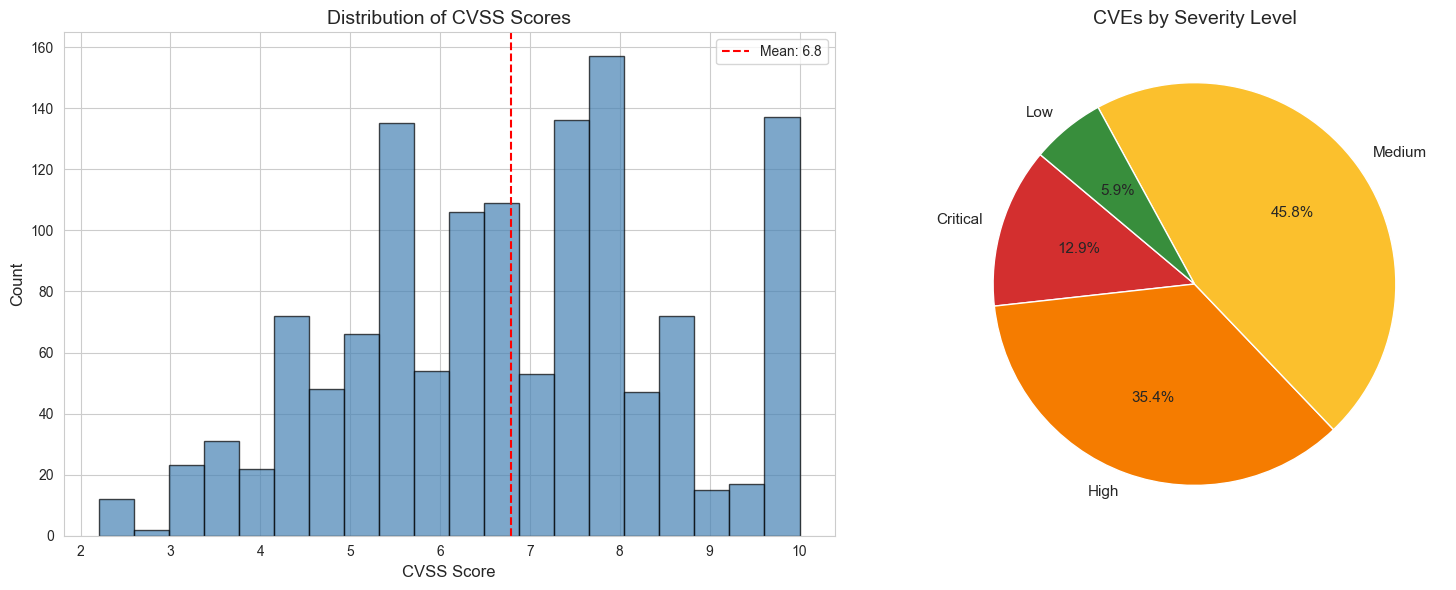


Severity Distribution:
  Critical: 169 (12.9%)
  High: 465 (35.4%)
  Medium: 602 (45.8%)
  Low: 78 (5.9%)


In [4]:
# Add severity labels
df['Severity'] = df['CVSS Score'].apply(get_severity_label)

# CVSS Score histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of CVSS scores
axes[0].hist(df['CVSS Score'].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('CVSS Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Distribution of CVSS Scores', fontsize=14)
axes[0].axvline(df['CVSS Score'].mean(), color='red', linestyle='--', label=f"Mean: {df['CVSS Score'].mean():.1f}")
axes[0].legend()

# Severity pie chart
severity_order = ['Critical', 'High', 'Medium', 'Low', 'None']
severity_counts = df['Severity'].value_counts()
severity_counts = severity_counts.reindex([s for s in severity_order if s in severity_counts.index])
colors = {'Critical': '#d32f2f', 'High': '#f57c00', 'Medium': '#fbc02d', 'Low': '#388e3c', 'None': '#90a4ae'}
pie_colors = [colors.get(s, '#90a4ae') for s in severity_counts.index]
axes[1].pie(severity_counts.values, labels=severity_counts.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('CVEs by Severity Level', fontsize=14)

plt.tight_layout()
plt.savefig('../models/severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSeverity Distribution:")
for sev, count in severity_counts.items():
    print(f"  {sev}: {count} ({count/len(df)*100:.1f}%)")

## 3. Vulnerability Type Analysis

In [5]:
# Classify vulnerability types from descriptions
df['Vulnerability_Type'] = df['Description'].apply(classify_vulnerability_type)

vuln_counts = df['Vulnerability_Type'].value_counts()
print("Vulnerability Type Distribution:")
for vtype, count in vuln_counts.items():
    print(f"  {vtype}: {count} ({count/len(df)*100:.1f}%)")

# Bar chart
fig = px.bar(x=vuln_counts.index, y=vuln_counts.values,
             labels={'x': 'Vulnerability Type', 'y': 'Count'},
             title='CVEs by Vulnerability Type',
             color=vuln_counts.values,
             color_continuous_scale='Reds')
fig.update_layout(xaxis_tickangle=-45, showlegend=False)
fig.show()

Vulnerability Type Distribution:
  Other: 413 (31.4%)
  Remote Code Execution: 238 (18.1%)
  Denial of Service: 145 (11.0%)
  SQL Injection: 125 (9.5%)
  Cross-Site Scripting (XSS): 122 (9.3%)
  Information Disclosure: 73 (5.6%)
  Buffer Overflow: 70 (5.3%)
  Command Injection: 43 (3.3%)
  CSRF: 43 (3.3%)
  Path Traversal: 16 (1.2%)
  Privilege Escalation: 10 (0.8%)
  SSRF: 8 (0.6%)
  Authentication Bypass: 8 (0.6%)


## 4. Affected Operating Systems / Software

In [6]:
# Analyze Affected OS
os_data = df[df['Affected OS'] != 'N/A']['Affected OS'].dropna()
print(f"CVEs with identified OS: {len(os_data)} / {len(df)}")

# Parse individual OS entries (they are comma-separated)
all_os = []
for os_str in os_data:
    for os_name in str(os_str).split(','):
        os_name = os_name.strip()
        # Extract vendor name
        parts = os_name.split()
        if len(parts) >= 1:
            vendor = parts[0]
            all_os.append(vendor)

os_counter = Counter(all_os)
top_vendors = os_counter.most_common(15)

fig = px.bar(x=[v[0] for v in top_vendors], y=[v[1] for v in top_vendors],
             labels={'x': 'Vendor/Platform', 'y': 'Number of CVEs'},
             title='Top 15 Most Affected Vendors/Platforms',
             color=[v[1] for v in top_vendors],
             color_continuous_scale='Blues')
fig.update_layout(xaxis_tickangle=-45, showlegend=False)
fig.show()

CVEs with identified OS: 431 / 1314


## 5. Attack Vector Analysis

In [7]:
# Parse Attack Vector string (CVSS vector string format)
def parse_attack_vector(av_string):
    """Extract attack vector type from CVSS vector string."""
    if not isinstance(av_string, str):
        return 'Unknown'
    if 'AV:N' in av_string:
        return 'Network'
    elif 'AV:A' in av_string:
        return 'Adjacent'
    elif 'AV:L' in av_string:
        return 'Local'
    elif 'AV:P' in av_string:
        return 'Physical'
    return 'Unknown'

df['Attack_Vector_Type'] = df['Attack Vector'].apply(parse_attack_vector)

av_counts = df['Attack_Vector_Type'].value_counts()
fig = px.pie(values=av_counts.values, names=av_counts.index,
             title='Attack Vector Distribution',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.show()

print("\nAttack Vector Distribution:")
for av, count in av_counts.items():
    print(f"  {av}: {count} ({count/len(df)*100:.1f}%)")


Attack Vector Distribution:
  Network: 893 (68.0%)
  Local: 343 (26.1%)
  Adjacent: 61 (4.6%)
  Physical: 17 (1.3%)


## 6. Severity vs Vulnerability Type Heatmap

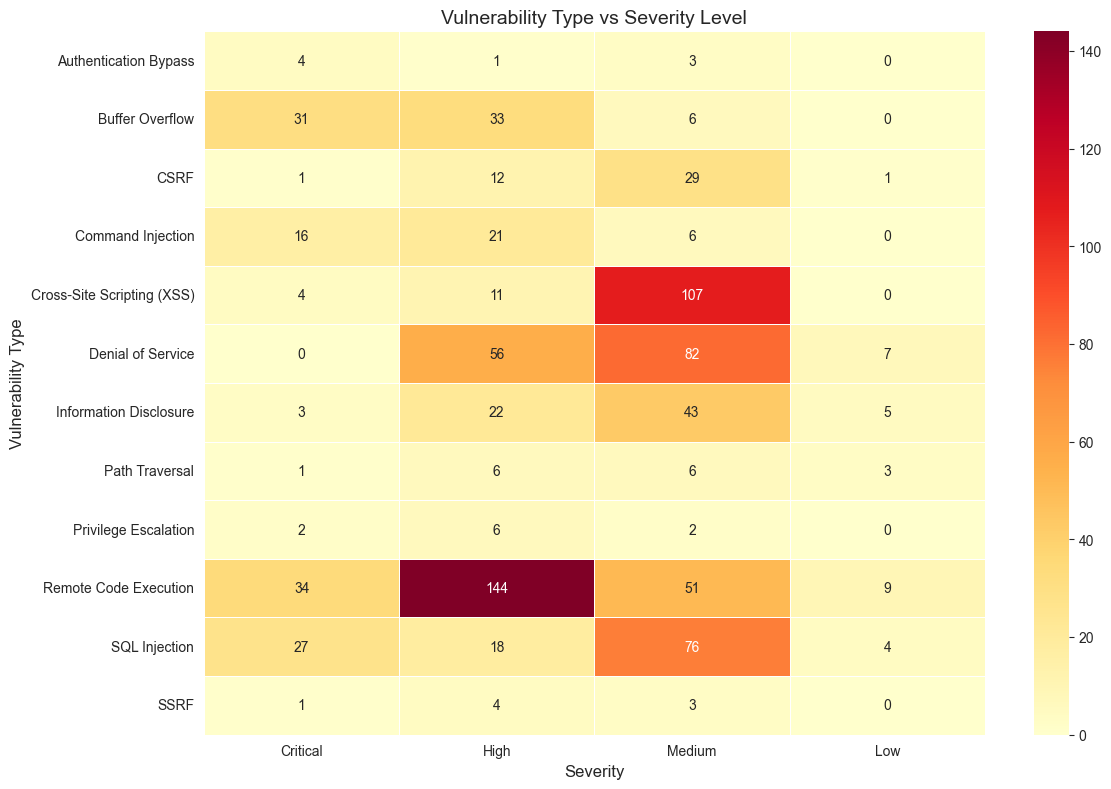

In [8]:
# Cross-tabulation: Severity vs Vulnerability Type
cross_tab = pd.crosstab(df['Vulnerability_Type'], df['Severity'])
severity_order_existing = [s for s in ['Critical', 'High', 'Medium', 'Low'] if s in cross_tab.columns]
cross_tab = cross_tab[severity_order_existing]

# Remove 'Other' for cleaner visualization
if 'Other' in cross_tab.index:
    cross_tab_clean = cross_tab.drop('Other')
else:
    cross_tab_clean = cross_tab

plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab_clean, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Vulnerability Type vs Severity Level', fontsize=14)
plt.xlabel('Severity', fontsize=12)
plt.ylabel('Vulnerability Type', fontsize=12)
plt.tight_layout()
plt.show()

## 7. CVE Year Analysis

In [9]:
# Extract year from CVE ID
df['CVE_Year'] = df['CVE ID'].str.extract(r'CVE-(\d{4})-').astype(float)

year_counts = df['CVE_Year'].value_counts().sort_index()
fig = px.bar(x=year_counts.index.astype(int), y=year_counts.values,
             labels={'x': 'Year', 'y': 'Number of CVEs'},
             title='CVEs by Year',
             color=year_counts.values,
             color_continuous_scale='Viridis')
fig.show()

## 8. Description Length vs Severity

In [10]:
df['Description_Length'] = df['Description'].str.len()

fig = px.box(df[df['Severity'].isin(['Critical', 'High', 'Medium', 'Low'])],
             x='Severity', y='Description_Length',
             category_orders={'Severity': ['Critical', 'High', 'Medium', 'Low']},
             title='Description Length by Severity Level',
             color='Severity',
             color_discrete_map={'Critical': '#d32f2f', 'High': '#f57c00',
                                  'Medium': '#fbc02d', 'Low': '#388e3c'})
fig.show()

## 9. Save Enhanced Dataset

Save the dataset with the new derived columns for use in subsequent notebooks.

In [11]:
# Save enhanced dataset
df.to_csv('../data/cve_explored.csv', index=False)
print(f"Enhanced dataset saved with {len(df)} records and columns: {list(df.columns)}")
print("\n✅ Data exploration complete!")

Enhanced dataset saved with 1314 records and columns: ['CVE ID', 'Description', 'CVSS Score', 'Attack Vector', 'Affected OS', 'Severity', 'Vulnerability_Type', 'Attack_Vector_Type', 'CVE_Year', 'Description_Length']

✅ Data exploration complete!
